# Xarray-Spatial Flood: Inundation, flood depth, curve number runoff, and travel time

Flood risk screening is one of the more practical applications of terrain analysis. Given a DEM and a few hydrological derivatives, you can estimate which cells flood at a given water level, how deep the water gets, how much rainfall becomes runoff, and how quickly water reaches the outlet. These tools won't replace a full hydraulic model, but they cover a lot of ground for planning and triage.

### What you'll build

1. Load a DEM and compute the hydrology stack (fill, flow direction, flow accumulation)
2. Derive HAND (Height Above Nearest Drainage) as the foundation for flood mapping
3. Map flood extent with `inundation` at several water levels
4. Compute per-cell water depth with `flood_depth`
5. Estimate rainfall-runoff partitioning with `curve_number_runoff`
6. Model overland flow timing with `travel_time`
7. Combine everything into a composite flood scenario map

![Flood analysis preview](images/flood_analysis_preview.png)

[Prepare the terrain](#Prepare-the-terrain) · [Compute HAND](#Compute-HAND) · [Inundation mapping](#Inundation-mapping) · [Flood depth](#Flood-depth) · [Curve number runoff](#Curve-number-runoff) · [Travel time](#Travel-time) · [Composite flood scenario](#Composite-flood-scenario)

Standard imports plus the four flood functions and a log-scale norm for stream rendering.

In [1]:
import numpy as np
import xarray as xr

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, LinearSegmentedColormap, LogNorm
from matplotlib.patches import Patch

import xrspatial
from xrspatial.flood import flood_depth, inundation, curve_number_runoff, travel_time

## Prepare the terrain

Same setup as the [hydrology guide](11_Hydrology.ipynb): load a Copernicus 30 m DEM tile, fill depressions, then compute flow direction and accumulation. If the remote tile is unavailable, we fall back to synthetic terrain.

In [2]:
try:
    import rasterio
    from rasterio.windows import Window

    url = (
        "https://copernicus-dem-30m.s3.amazonaws.com/"
        "Copernicus_DSM_COG_10_N46_00_W123_00_DEM/"
        "Copernicus_DSM_COG_10_N46_00_W123_00_DEM.tif"
    )

    with rasterio.open(url) as src:
        window = Window(col_off=2400, row_off=2400, width=600, height=600)
        data = src.read(1, window=window).astype(np.float64)
        nodata = src.nodata

    if nodata is not None:
        data[data == nodata] = np.nan

    H, W = data.shape
    dem = xr.DataArray(data, dims=['y', 'x'], name='elevation',
                       attrs={'res': (1, 1)})
    dem['y'] = np.linspace(H - 1, 0, H)
    dem['x'] = np.linspace(0, W - 1, W)
    print(f"Loaded Copernicus 30m DEM: {dem.shape}")

except Exception as e:
    print(f"Remote DEM unavailable ({e}), generating synthetic terrain")
    H, W = 600, 600
    dem = xr.DataArray(np.zeros((H, W)), dims=['y', 'x'])
    dem = dem.xrs.generate_terrain(seed=10)
    dem.name = 'elevation'
    print(f"Generated terrain: {dem.shape}")

Loaded Copernicus 30m DEM: (600, 600)


In [3]:
# Fill depressions, resolve flats, compute flow direction and accumulation.
# This is the same preprocessing from the hydrology guide.
dem_filled = xrspatial.fill(dem)

rng = np.random.RandomState(42)
dem_filled.values += rng.uniform(0, 0.001, dem_filled.shape)
dem_filled = xrspatial.fill(dem_filled)
rng2 = np.random.RandomState(123)
dem_filled.values += rng2.uniform(0, 1e-6, dem_filled.shape)

flow_dir = xrspatial.flow_direction(dem_filled)
flow_accum = xrspatial.flow_accumulation(flow_dir)

print(f"Flow accumulation range: {np.nanmin(flow_accum.values):.0f} to "
      f"{np.nanmax(flow_accum.values):.0f}")

Flow accumulation range: 1 to 14827


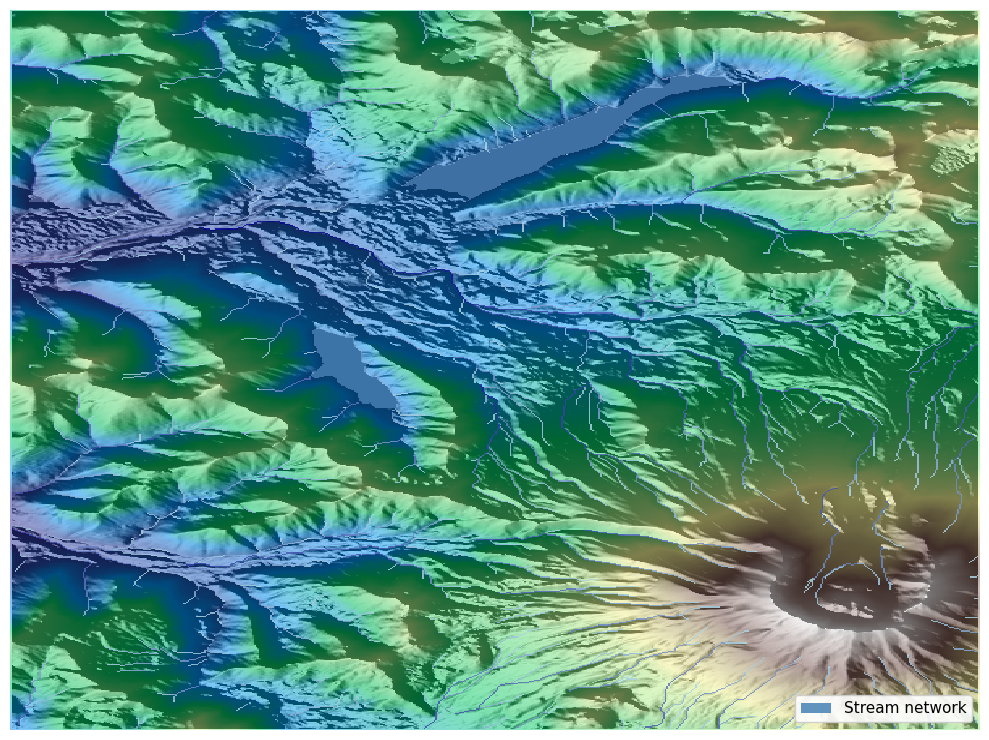

In [4]:
# Build a hillshade basemap we'll reuse throughout
hillshade = xrspatial.hillshade(dem)

stream_cmap = LinearSegmentedColormap.from_list('water', ['lightblue', 'darkblue'])

# Extract the stream network for context
threshold = 200
streams = xr.where(flow_accum >= threshold, flow_accum, np.nan)
streams.name = 'streams'

stream_positives = streams.values[streams.values > 0]
stream_vmin = max(np.nanmin(stream_positives), 1e-10)

fig, ax = plt.subplots(figsize=(10, 7.5))
hillshade.plot.imshow(ax=ax, cmap='gray', add_colorbar=False)
dem.plot.imshow(ax=ax, cmap='terrain', alpha=0.5, add_colorbar=False)
streams.plot.imshow(ax=ax, cmap=stream_cmap, alpha=220/255, add_colorbar=False,
                    norm=LogNorm(vmin=stream_vmin))
ax.legend(handles=[Patch(facecolor='steelblue', alpha=0.86, label='Stream network')],
          loc='lower right', fontsize=11, framealpha=0.9)
ax.set_axis_off()
plt.tight_layout()

Terrain colored by elevation with the extracted stream network overlaid in blue. Streams are cells where flow accumulation exceeds 200 upstream contributors.

## Compute HAND

[HAND](https://doi.org/10.1016/j.rse.2011.02.012) (Height Above Nearest Drainage) measures the vertical distance from each cell to the stream channel it drains into. Cells sitting on the channel have HAND near zero; cells on ridges have high values. All four flood functions use HAND as their primary input: a cell floods when the channel water level exceeds its HAND value.

The plot below shows HAND across the grid, from dark blue (low, near channels) to red (high, on ridges).

HAND range: 0.0 to 930.9 m


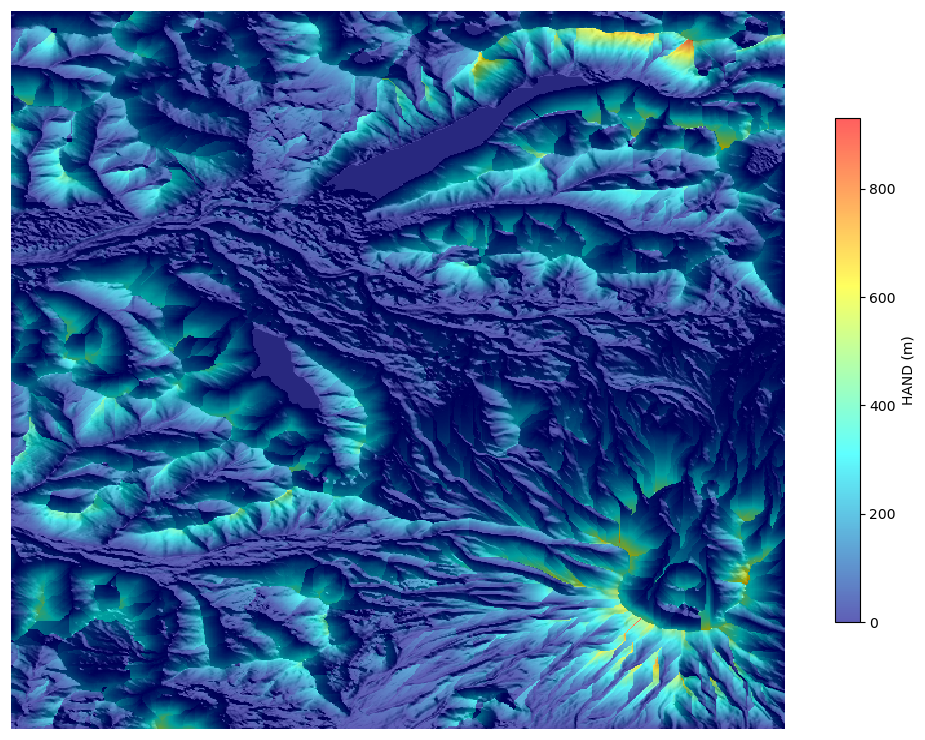

In [5]:
hand_raster = xrspatial.hand(flow_dir, flow_accum, dem_filled, threshold=threshold)

print(f"HAND range: {np.nanmin(hand_raster.values):.1f} to "
      f"{np.nanmax(hand_raster.values):.1f} m")

hand_cmap = LinearSegmentedColormap.from_list('hand', ['darkblue', 'cyan', 'yellow', 'red'])

fig, ax = plt.subplots(figsize=(10, 7.5))
hillshade.plot.imshow(ax=ax, cmap='gray', add_colorbar=False)
hand_raster.plot.imshow(ax=ax, cmap=hand_cmap, alpha=160/255, add_colorbar=True,
                        cbar_kwargs={'label': 'HAND (m)', 'shrink': 0.7})
ax.set_axis_off()
plt.tight_layout()

<div class="alert alert-block alert-warning">
<b>HAND depends on the stream threshold.</b> A lower threshold produces more drainage channels, which lowers HAND values everywhere and increases the estimated flood extent. Choose the threshold based on how dense the real channel network is in your study area, not just what looks good on screen.
</div>

## Inundation mapping

The simplest flood question: which cells go underwater? `inundation(hand_raster, water_level)` returns 1.0 where HAND is at or below the water level, 0.0 elsewhere, and preserves NaN from the input. We'll sweep a few water levels to see how the flood footprint grows.

The table below shows flooded cell counts for water levels of 2, 5, 10, and 20 metres. The map shows the 10 m scenario.

In [6]:
for wl in [2, 5, 10, 20]:
    mask = inundation(hand_raster, water_level=wl)
    n_flooded = int(np.nansum(mask.values))
    pct = 100 * n_flooded / (H * W)
    print(f"Water level {wl:2d} m: {n_flooded:>6d} cells flooded ({pct:.1f}%)")

Water level  2 m:  29085 cells flooded (8.1%)
Water level  5 m:  40494 cells flooded (11.2%)
Water level 10 m:  58990 cells flooded (16.4%)
Water level 20 m:  90039 cells flooded (25.0%)


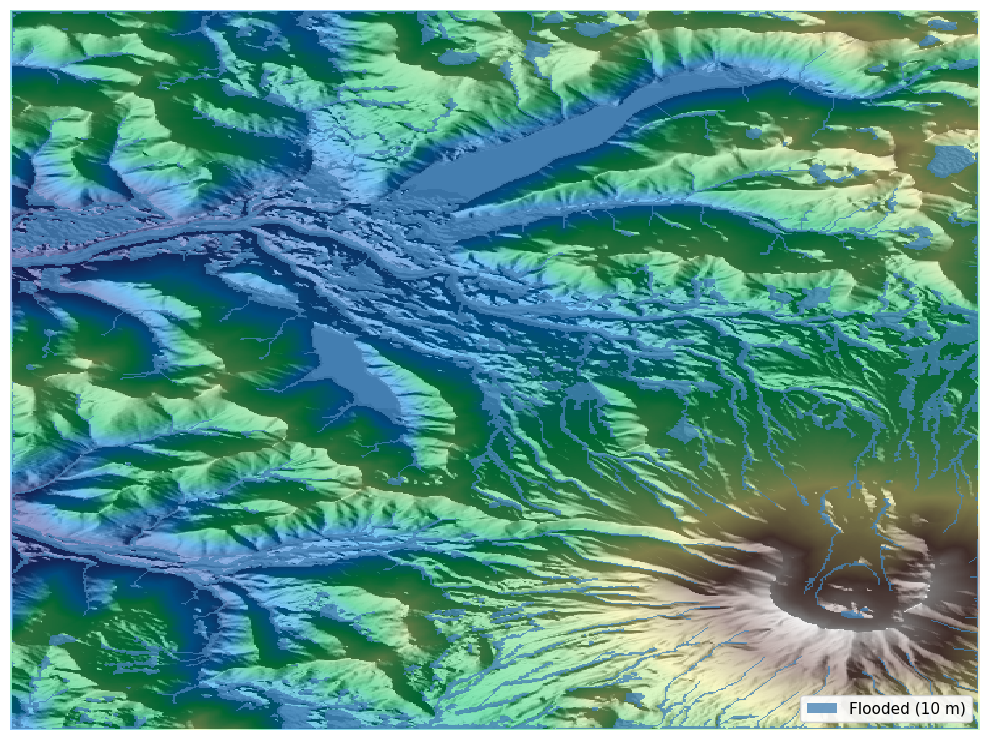

In [7]:
# Visualize the 10 m flood extent
flood_mask = inundation(hand_raster, water_level=10)

# Replace 0s with NaN so only flooded cells render
flood_viz = xr.where(flood_mask == 1.0, 1.0, np.nan)
flood_viz.name = 'inundation'

fig, ax = plt.subplots(figsize=(10, 7.5))
hillshade.plot.imshow(ax=ax, cmap='gray', add_colorbar=False)
dem.plot.imshow(ax=ax, cmap='terrain', alpha=0.5, add_colorbar=False)
flood_viz.plot.imshow(ax=ax, cmap=ListedColormap(['steelblue']),
                      alpha=200/255, add_colorbar=False)
ax.legend(handles=[Patch(facecolor='steelblue', alpha=0.78, label='Flooded (10 m)')],
          loc='lower right', fontsize=11, framealpha=0.9)
ax.set_axis_off()
plt.tight_layout()

<div class="alert alert-block alert-info">
<b>Uniform vs. varying water levels.</b> Here we apply the same water level to every channel reach. In practice, water levels differ along the network depending on contributing area, channel geometry, and upstream inflow. For reach-specific water levels, compute inundation per sub-catchment and mosaic the results.
</div>

## Flood depth

Knowing which cells flood is useful, but damage estimation needs depth. `flood_depth(hand_raster, water_level)` returns `water_level - HAND` where the cell is inundated, NaN elsewhere. A cell with HAND = 3 m under a 10 m water level sits under 7 m of water.

The plot shows flood depth at the 10 m water level, from shallow (yellow) to deep (dark red).

Flood depth at water_level=10 m:
  min:    0.00 m
  median: 7.88 m
  max:    10.00 m


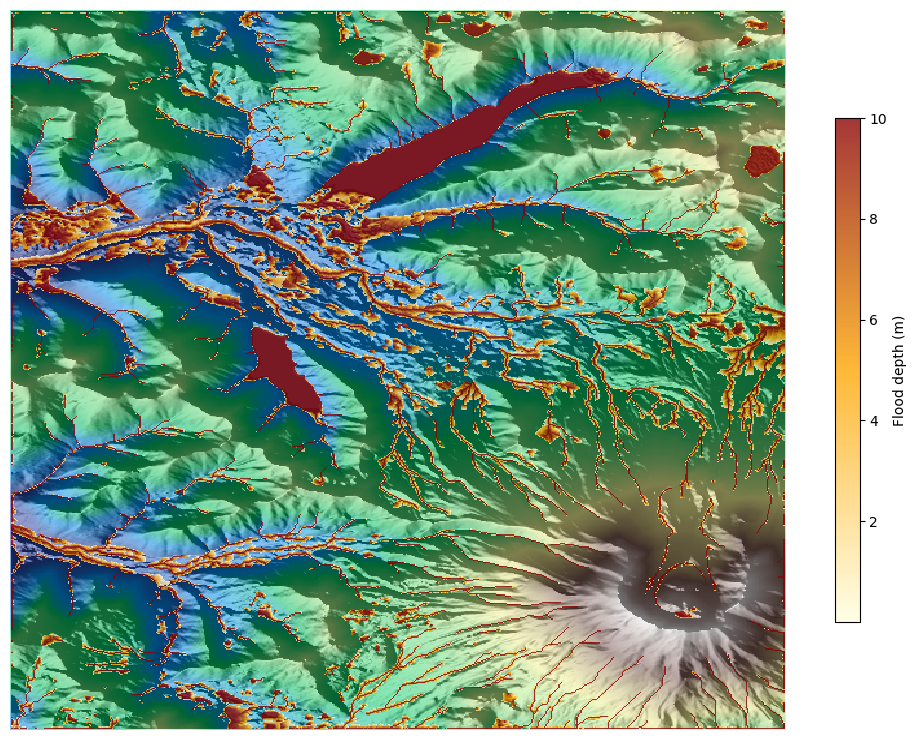

In [8]:
depth = flood_depth(hand_raster, water_level=10)

# Stats on flooded cells only
flooded_vals = depth.values[~np.isnan(depth.values)]
print(f"Flood depth at water_level=10 m:")
print(f"  min:    {flooded_vals.min():.2f} m")
print(f"  median: {np.median(flooded_vals):.2f} m")
print(f"  max:    {flooded_vals.max():.2f} m")

heat_cmap = LinearSegmentedColormap.from_list('heat', ['lightyellow', 'orange', 'darkred'])

fig, ax = plt.subplots(figsize=(10, 7.5))
hillshade.plot.imshow(ax=ax, cmap='gray', add_colorbar=False)
dem.plot.imshow(ax=ax, cmap='terrain', alpha=0.5, add_colorbar=False)
depth.plot.imshow(ax=ax, cmap=heat_cmap, alpha=200/255, add_colorbar=True,
                  cbar_kwargs={'label': 'Flood depth (m)', 'shrink': 0.7})
ax.set_axis_off()
plt.tight_layout()

## Curve number runoff

How much of a rainstorm actually becomes runoff? The [SCS/NRCS curve number method](https://www.nrcs.usda.gov/sites/default/files/2022-09/Chapter10.pdf) gives a quick estimate. CN ranges from 0 to 100: low values (30-50) mean permeable soil and good ground cover, so most rain infiltrates; high values (80-98) mean impervious surfaces or saturated soil, so most rain runs off.

First we compare a uniform 100 mm storm under different land cover assumptions, then apply a spatially varying CN raster.

In [9]:
# 100 mm rainfall everywhere
rainfall = xr.DataArray(
    np.full((H, W), 100.0, dtype=np.float64),
    dims=['y', 'x'], coords=dem.coords,
    attrs=dem.attrs, name='rainfall',
)

# Compare CN values: forest (55), pasture (70), suburban (80), pavement (95)
for label, cn in [('forest', 55), ('pasture', 70), ('suburban', 80), ('pavement', 95)]:
    q = curve_number_runoff(rainfall, curve_number=cn)
    print(f"CN={cn:2d} ({label:>9s}): {q.values[0, 0]:.1f} mm runoff from 100 mm rain")

CN=55 (   forest): 12.8 mm runoff from 100 mm rain
CN=70 (  pasture): 32.7 mm runoff from 100 mm rain
CN=80 ( suburban): 50.5 mm runoff from 100 mm rain
CN=95 ( pavement): 85.6 mm runoff from 100 mm rain


The function also accepts a spatially varying CN raster. In practice you'd derive this from a land cover map. Here we approximate one: valley floors (low HAND) get a higher CN representing developed land, and hillsides get a lower CN representing forest.

Spatially varying runoff:
  valley (CN=85): 61.0 mm
  hills  (CN=55): 12.8 mm


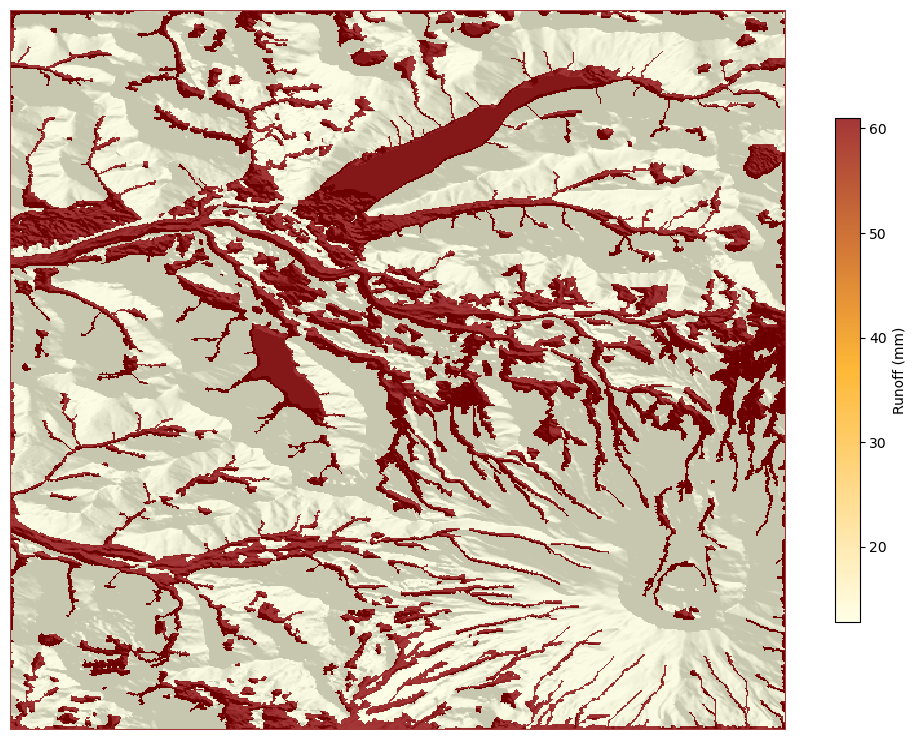

In [10]:
# Simple CN map: low HAND -> urban-ish (CN=85), high HAND -> forested (CN=55)
hand_filled = hand_raster.fillna(0)
cn_data = xr.where(hand_filled < 20, 85.0, 55.0)
cn_raster = cn_data.astype(np.float64)
cn_raster.name = 'curve_number'

runoff = curve_number_runoff(rainfall, curve_number=cn_raster)

print(f"Spatially varying runoff:")
print(f"  valley (CN=85): {runoff.values[cn_raster.values == 85].mean():.1f} mm")
print(f"  hills  (CN=55): {runoff.values[cn_raster.values == 55].mean():.1f} mm")

heat_cmap = LinearSegmentedColormap.from_list('heat', ['lightyellow', 'orange', 'darkred'])

fig, ax = plt.subplots(figsize=(10, 7.5))
hillshade.plot.imshow(ax=ax, cmap='gray', add_colorbar=False)
runoff.plot.imshow(ax=ax, cmap=heat_cmap, alpha=200/255, add_colorbar=True,
                   cbar_kwargs={'label': 'Runoff (mm)', 'shrink': 0.7})
ax.set_axis_off()
plt.tight_layout()

<div class="alert alert-block alert-warning">
<b>Curve number limitations.</b> The SCS method was designed for single-peak storms on small agricultural watersheds. It does not account for snowmelt, baseflow, antecedent soil moisture, or multi-day events. CN tables in TR-55 are indexed by land cover and hydrologic soil group; using a realistic spatially varying CN matters more than the rainfall resolution.
</div>

## Travel time

How long does runoff take to reach the outlet? `travel_time` estimates this with a simplified [Manning's equation](https://en.wikipedia.org/wiki/Manning_formula): velocity scales with the square root of the slope tangent and inversely with roughness coefficient *n*. The maximum travel time across the grid is the *time of concentration*, a key parameter for flood peak estimation.

Near-zero slopes get clamped to `tan(0.001 deg)` to avoid division by zero. The plot shows travel time across the grid, with the roughness comparison printed below.

In [11]:
slope_raster = xrspatial.slope(dem_filled)
fl_raster = xrspatial.flow_length(flow_dir)

print(f"Slope range: {np.nanmin(slope_raster.values):.2f} to "
      f"{np.nanmax(slope_raster.values):.1f} degrees")
print(f"Flow length range: {np.nanmin(fl_raster.values):.0f} to "
      f"{np.nanmax(fl_raster.values):.0f} cells")

Slope range: 0.00 to 89.0 degrees
Flow length range: 0 to 416 cells


Travel time range: 0.0 to 205.2
Time of concentration (max travel time): 205.2


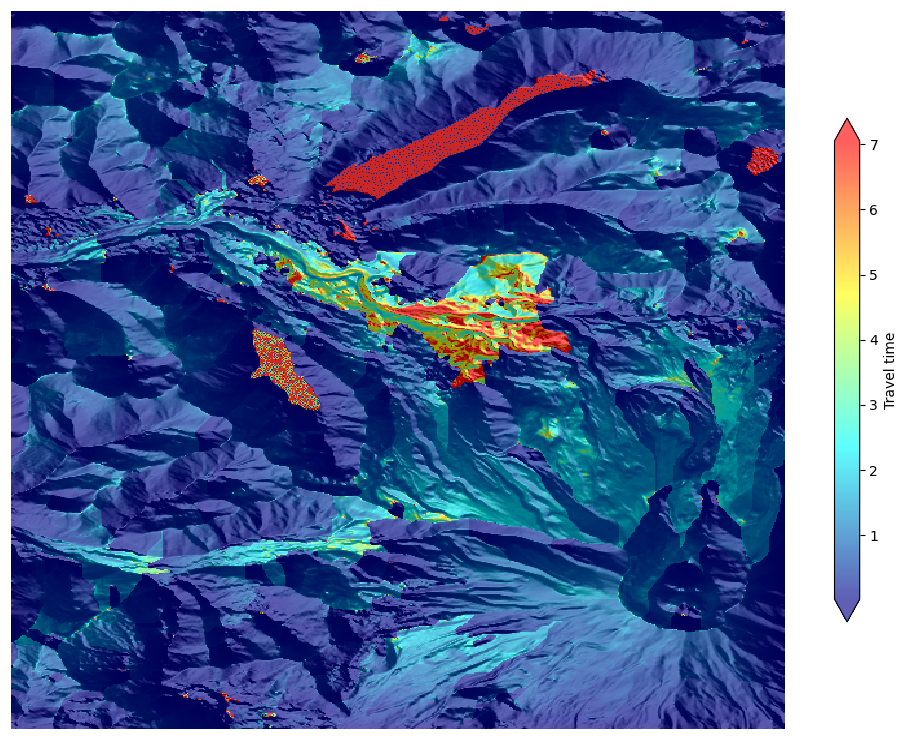

In [12]:
# Manning's n = 0.03 is typical for natural channels.
tt = travel_time(fl_raster, slope_raster, mannings_n=0.03)

tt_vals = tt.values[~np.isnan(tt.values)]
tc = tt_vals.max()
print(f"Travel time range: {tt_vals.min():.1f} to {tc:.1f}")
print(f"Time of concentration (max travel time): {tc:.1f}")

tt_cmap = LinearSegmentedColormap.from_list('tt', ['darkblue', 'cyan', 'yellow', 'red'])
vmin, vmax = np.nanpercentile(tt_vals[np.isfinite(tt_vals)], [2, 98])

fig, ax = plt.subplots(figsize=(10, 7.5))
hillshade.plot.imshow(ax=ax, cmap='gray', add_colorbar=False)
tt.plot.imshow(ax=ax, cmap=tt_cmap, alpha=160/255, vmin=vmin, vmax=vmax,
               add_colorbar=True,
               cbar_kwargs={'label': 'Travel time', 'shrink': 0.7})
ax.set_axis_off()
plt.tight_layout()

In [13]:
# Compare roughness: smoother surface (channel) vs rougher (vegetated hillside)
tt_smooth = travel_time(fl_raster, slope_raster, mannings_n=0.03)
tt_rough  = travel_time(fl_raster, slope_raster, mannings_n=0.06)

print(f"Time of concentration:")
print(f"  n=0.03 (channel):    {np.nanmax(tt_smooth.values):.1f}")
print(f"  n=0.06 (vegetated):  {np.nanmax(tt_rough.values):.1f}")
print(f"  ratio: {np.nanmax(tt_rough.values) / np.nanmax(tt_smooth.values):.2f}x")

Time of concentration:
  n=0.03 (channel):    205.2
  n=0.06 (vegetated):  410.5
  ratio: 2.00x


<div class="alert alert-block alert-warning">
<b>Units depend on your inputs.</b> Travel time units come from dividing flow length units by velocity units. If flow length is in cells (as here) and slope is in degrees, the output is in arbitrary time units. For physically meaningful travel times, use flow length in metres and check that Manning's n matches the velocity units you want (m/s gives seconds).
</div>

## Composite flood scenario

In practice you'd run these in sequence: estimate how much rain becomes runoff (`curve_number_runoff`), pick a water level scenario, map the flood extent and depth (`inundation`, `flood_depth`), and check how quickly water arrives at the outlet (`travel_time`).

Below we overlay flood depth on the terrain with the stream network, giving a single-map summary of the 10 m flood scenario.

10 m flood scenario: 58990 cells flooded (16.4% of grid)
Median depth in flooded area: 7.9 m


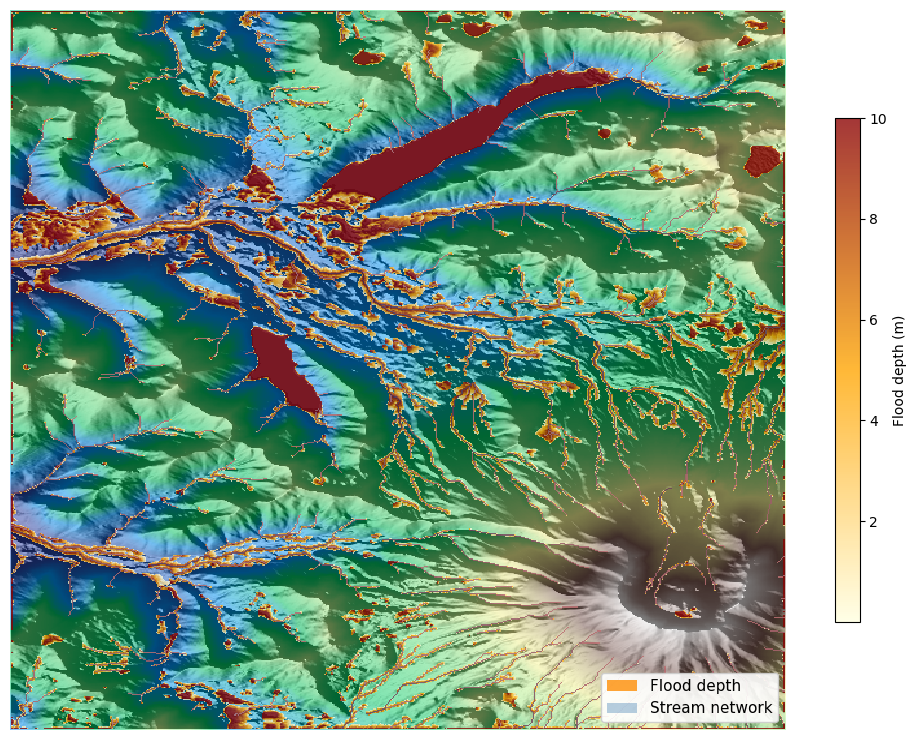

In [14]:
# Final composite: 10 m flood scenario
import os as _os

depth_10m = flood_depth(hand_raster, water_level=10)

n_flooded = int(np.sum(~np.isnan(depth_10m.values)))
pct_flooded = 100 * n_flooded / (H * W)
print(f"10 m flood scenario: {n_flooded} cells flooded ({pct_flooded:.1f}% of grid)")
print(f"Median depth in flooded area: {np.nanmedian(depth_10m.values):.1f} m")

heat_cmap = LinearSegmentedColormap.from_list('heat', ['lightyellow', 'orange', 'darkred'])

fig, ax = plt.subplots(figsize=(10, 7.5))
hillshade.plot.imshow(ax=ax, cmap='gray', add_colorbar=False)
dem.plot.imshow(ax=ax, cmap='terrain', alpha=0.5, add_colorbar=False)
depth_10m.plot.imshow(ax=ax, cmap=heat_cmap, alpha=200/255, add_colorbar=True,
                      cbar_kwargs={'label': 'Flood depth (m)', 'shrink': 0.7})
streams.plot.imshow(ax=ax, cmap='Blues', alpha=100/255, add_colorbar=False,
                    norm=LogNorm(vmin=stream_vmin))
ax.legend(handles=[Patch(facecolor='darkorange', alpha=0.78, label='Flood depth'),
                   Patch(facecolor='steelblue', alpha=0.39, label='Stream network')],
          loc='lower right', fontsize=11, framealpha=0.9)
ax.set_axis_off()
plt.tight_layout()

# Save preview image
_os.makedirs('images', exist_ok=True)
fig.savefig('images/flood_analysis_preview.png', bbox_inches='tight', dpi=120)

<div class="alert alert-block alert-danger">
<b>DEM resolution matters.</b> At 30 m cell size, narrow floodplains and small channels can be missed entirely, leading to underestimated flood extent in tight valleys. LiDAR DEMs at 1-5 m resolution give much better results for local studies. For anything beyond screening, pair these tools with a proper hydraulic model (HEC-RAS, LISFLOOD, etc.) that simulates flood wave propagation over time.
</div>

### References

- Nobre, A.D. et al. (2011). HAND, a new terrain descriptor using SRTM-DEM: [doi:10.1016/j.rse.2011.02.012](https://doi.org/10.1016/j.rse.2011.02.012)
- USDA-NRCS (1986). Urban Hydrology for Small Watersheds, TR-55: [https://www.nrcs.usda.gov/sites/default/files/2022-09/Chapter10.pdf](https://www.nrcs.usda.gov/sites/default/files/2022-09/Chapter10.pdf)
- Manning's formula: [https://en.wikipedia.org/wiki/Manning_formula](https://en.wikipedia.org/wiki/Manning_formula)
- Copernicus DEM on AWS: [https://registry.opendata.aws/copernicus-dem/](https://registry.opendata.aws/copernicus-dem/)